In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/processed/cleaned_sales_data.csv', parse_dates=['InvoiceDate'])

## Total revenue by month

In [8]:
df['revenue_by_month'] = df['Quantity'] * df['UnitPrice']

In [9]:
df['month'] = df['InvoiceDate'].dt.to_period('M')

In [12]:
monthly_revenue = df.groupby('month')['revenue_by_month'].sum().reset_index()
monthly_revenue.to_csv('../outputs/reports/monthly_revenue.csv', index=False)

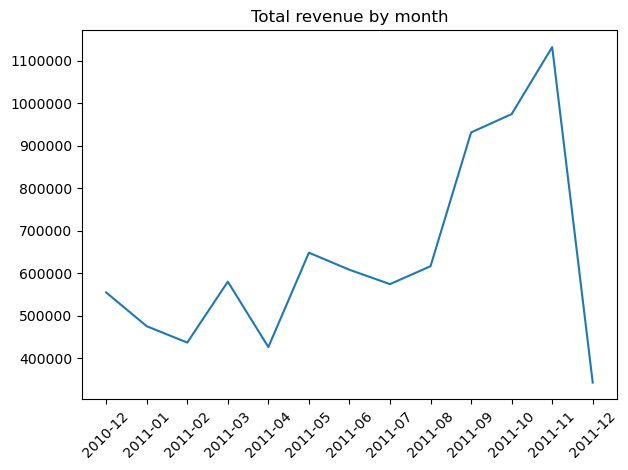

In [6]:
monthly_revenue['month'] = monthly_revenue['month'].astype('str')

plt.figure()
plt.plot(monthly_revenue['month'], monthly_revenue['revenue_by_month'])
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.title(label='Total revenue by month')
plt.tight_layout()
plt.savefig('../outputs/graphs/monthly_revenue.png')